In [ ]:
#01. Data Loading
#02. Data Quality Assessment
#03. Data Cleaning
#04. Univariate Analysis
#05. Bivariate Analysis
#06. Multivariate Analysis
#07. Feature Engineering
#08. Statistical Analysis
#09. Outlier Detection
#10. Insights & Conclusions

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats

plt.style.use('ggplot')

In [ ]:
editions = pd.read_csv('wc_all_editions.csv')
matches = pd.read_csv('wc_all_matches.csv')
scorers = pd.read_csv('wc_top_scorers.csv')
teams2026 = pd.read_csv('wc_2026_teams.csv')
fixtures2026 = pd.read_csv('wc_2026_fixtures.csv')

In [ ]:
print(editions.shape)
print(matches.shape)
print(scorers.shape)
print(teams2026.shape)
print(fixtures2026.shape)

(22, 20)
(184, 11)
(22, 11)
(48, 7)
(104, 15)


In [ ]:
editions.info()
matches.info()
scorers.info()
teams2026.info()
fixtures2026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   edition             22 non-null     int64  
 1   year                22 non-null     int64  
 2   host                22 non-null     object 
 3   champion            22 non-null     object 
 4   runner_up           22 non-null     object 
 5   third_place         22 non-null     object 
 6   fourth_place        22 non-null     object 
 7   teams               22 non-null     int64  
 8   matches             22 non-null     int64  
 9   goals               22 non-null     int64  
 10  goals_per_match     22 non-null     float64
 11  attendance          22 non-null     int64  
 12  top_scorer          22 non-null     object 
 13  top_scorer_country  22 non-null     object 
 14  top_scorer_goals    22 non-null     int64  
 15  start_date          22 non-null     object 
 16  end_date  

In [ ]:
editions.isnull().sum()

matches.isnull().sum()

scorers.isnull().sum()

teams2026.isnull().sum()

fixtures2026.isnull().sum()

,0
group,32
stage,0
team1,0
team2,0
venue,0
city,0
country,0
date,0
kickoff_et,0
team1_confederation,32


In [ ]:
print(editions.duplicated().sum())
print(matches.duplicated().sum())
print(scorers.duplicated().sum())
print(teams2026.duplicated().sum())
print(fixtures2026.duplicated().sum())

0
0
0
0
0


In [ ]:
matches.drop_duplicates(inplace=True)
scorers.drop_duplicates(inplace=True)
teams2026.drop_duplicates(inplace=True)
fixtures2026.drop_duplicates(inplace=True)
editions.drop_duplicates(inplace=True)

In [ ]:
editions.describe()

matches.describe()

scorers.describe()

teams2026.describe()

fixtures2026.describe()

,team1_fifa_rank,team2_fifa_rank
count,72.000000,72.000000
mean,30.208333,37.916667
std,24.521297,23.836739
min,1.000000,1.000000
25%,9.750000,17.750000
50%,24.000000,35.500000
75%,44.000000,57.750000
max,95.000000,95.000000


In [ ]:
matches['TotalGoals'] = (
    matches['score1'] +
    matches['score2']
)
print(matches['TotalGoals'])
print(matches['TotalGoals'].describe())

0      5
1      3
2      3
3      1
4      9
      ..
179    3
180    3
181    2
182    3
183    6
Name: TotalGoals, Length: 184, dtype: int64
count    184.000000
mean       3.510870
std        2.532821
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       13.000000
Name: TotalGoals, dtype: float64


count    184.000000
mean       3.510870
std        2.532821
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       13.000000
Name: TotalGoals, dtype: float64


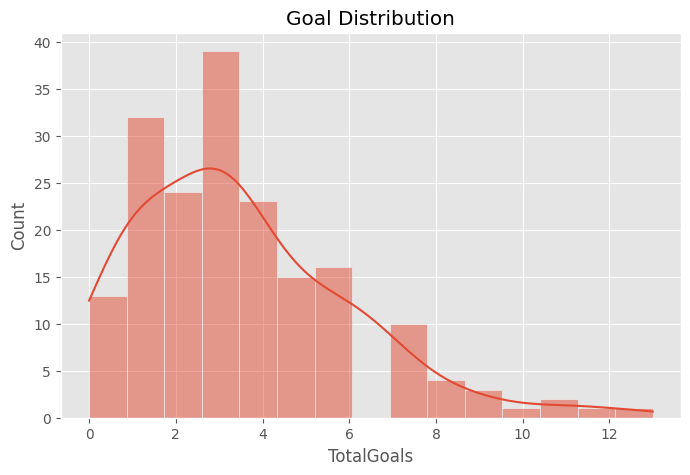

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    matches['TotalGoals'],
    bins=15,
    kde=True
)
plt.title('Goal Distribution')
plt.show()

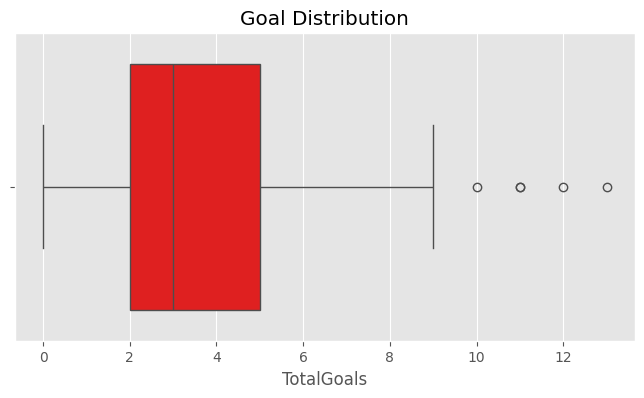

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=matches['TotalGoals'],
    color='red'
)
plt.title('Goal Distribution')
plt.show()

In [ ]:
highest = matches.sort_values(
    by='TotalGoals',
    ascending=False
)

highest.head(10)

,year,stage,team1,score1,score2,team2,venue,city,country,date,notes,TotalGoals
57,1970,Group Stage,West Germany,3,10,Bulgaria,Estadio Nou Camp,León,Mexico,1970-06-02,NaN,13
29,1954,Quarter-final,Austria,7,5,Switzerland,Hardturm,Lausanne,Switzerland,1954-06-26,Highest scoring WC match ever,12
28,1954,Group Stage,West Germany,3,8,Hungary,Wankdorf,Bern,Switzerland,1954-06-20,NaN,11
15,1938,Round of 16,Brazil,6,5,Poland,Stade de la Meinau,Strasbourg,France,1938-06-05,AET - 11 goals!,11
35,1958,Group Stage,France,7,3,Paraguay,Idrottsparken,Norrköping,Sweden,1958-06-08,Fontaine hat-trick,10
27,1954,Group Stage,Hungary,9,0,South Korea,Hardturm,Zürich,Switzerland,1954-06-17,NaN,9
39,1958,3rd Place,France,6,3,West Germany,Ullevi,Gothenburg,Sweden,1958-06-28,Fontaine scores 4,9
4,1930,Group Stage,Argentina,6,3,USA,Estadio Centenario,Montevideo,Uruguay,1930-07-26,NaN,9
24,1950,Final Round,Brazil,7,1,Sweden,Estádio do Maracanã,Rio de Janeiro,Brazil,1950-07-09,NaN,8
50,1966,Quarter-final,North Korea,3,5,Portugal,Goodison Park,Liverpool,England,1966-07-23,Eusébio scores 4,8


In [ ]:
champions = editions['champion'].value_counts()

champions


champion
Brazil          5
Italy           4
West Germany    3
Argentina       3
Uruguay         2
France          2
England         1
Spain           1
Germany         1
Name: count, dtype: int64


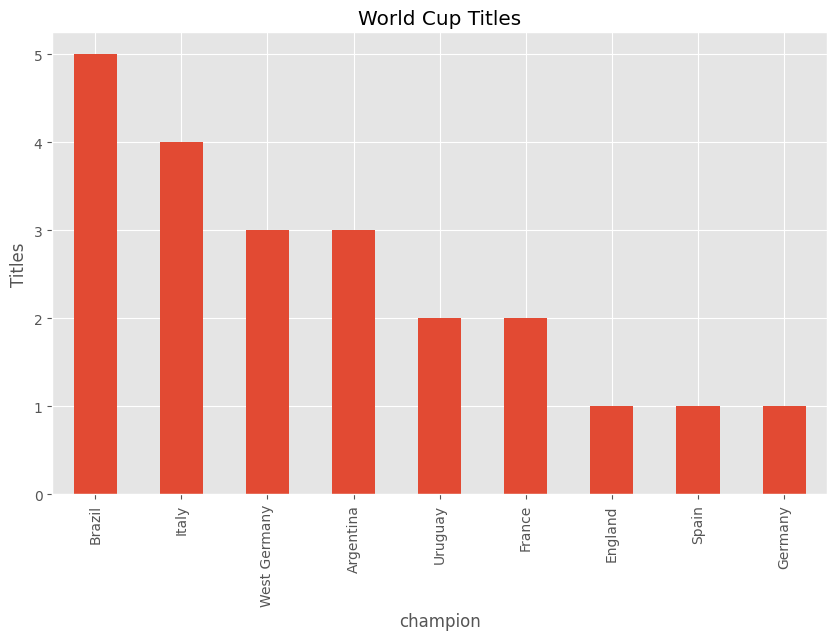

In [ ]:
plt.figure(figsize=(10,6))

champions.plot(kind='bar')
print(champions)
plt.title('World Cup Titles')
plt.ylabel('Titles')

plt.show()

0     1930
1     1934
2     1938
3     1950
4     1954
5     1958
6     1962
7     1966
8     1970
9     1974
10    1978
11    1982
12    1986
13    1990
14    1994
15    1998
16    2002
17    2006
18    2010
19    2014
20    2018
21    2022
Name: year, dtype: int64
0      8
1      5
2      7
3      8
4     11
5     13
6      4
7      9
8     10
9      7
10     6
11     6
12     6
13     6
14     6
15     6
16     8
17     5
18     5
19     6
20     6
21     8
Name: top_scorer_goals, dtype: int64


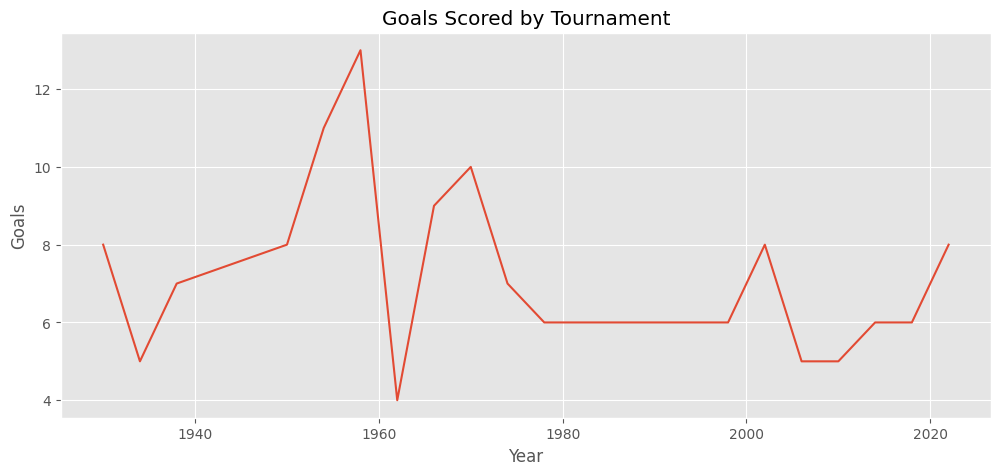

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    editions['year'],
    editions['top_scorer_goals']
)
print(editions['year'])
print(editions['top_scorer_goals'])
plt.xlabel('Year')
plt.ylabel('Goals')

plt.title('Goals Scored by Tournament')

plt.show()

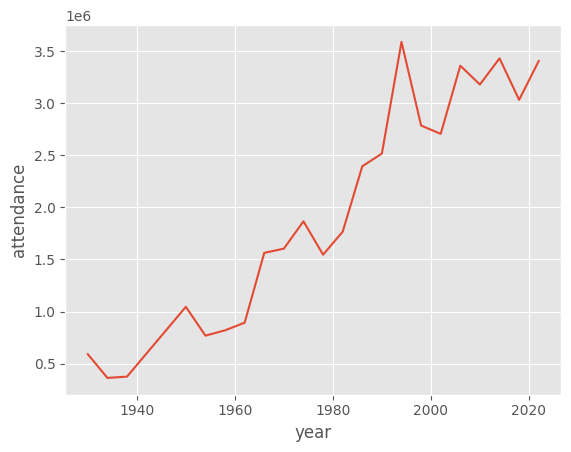

In [ ]:
sns.lineplot(
    data=editions,
    x='year',
    y='attendance'
)

plt.show()

In [ ]:
top10 = scorers.nlargest(
    10,
    'goals'
)
print(top10)

    edition  year             player       country position  goals  assists  \
5         6  1958      Just Fontaine        France       FW     13        0   
4         5  1954      Sándor Kocsis       Hungary       FW     11        0   
8         9  1970        Gerd Müller  West Germany       FW     10        0   
7         8  1966            Eusébio      Portugal       FW      9        0   
0         1  1930  Guillermo Stábile     Argentina       FW      8        0   
3         4  1950             Ademir        Brazil       FW      8        0   
16       17  2002            Ronaldo        Brazil       FW      8        0   
21       22  2022      Kylian Mbappé        France       FW      8        2   
2         3  1938           Leônidas        Brazil       FW      7        0   
9        10  1974      Grzegorz Lato        Poland       FW      7        0   

    penalties  matches_played               host  team_result  
5           0               6             Sweden  Third place  
4 

    edition  year             player       country position  goals  assists  \
5         6  1958      Just Fontaine        France       FW     13        0   
4         5  1954      Sándor Kocsis       Hungary       FW     11        0   
8         9  1970        Gerd Müller  West Germany       FW     10        0   
7         8  1966            Eusébio      Portugal       FW      9        0   
0         1  1930  Guillermo Stábile     Argentina       FW      8        0   
3         4  1950             Ademir        Brazil       FW      8        0   
16       17  2002            Ronaldo        Brazil       FW      8        0   
21       22  2022      Kylian Mbappé        France       FW      8        2   
2         3  1938           Leônidas        Brazil       FW      7        0   
9        10  1974      Grzegorz Lato        Poland       FW      7        0   

    penalties  matches_played               host  team_result  
5           0               6             Sweden  Third place  
4 

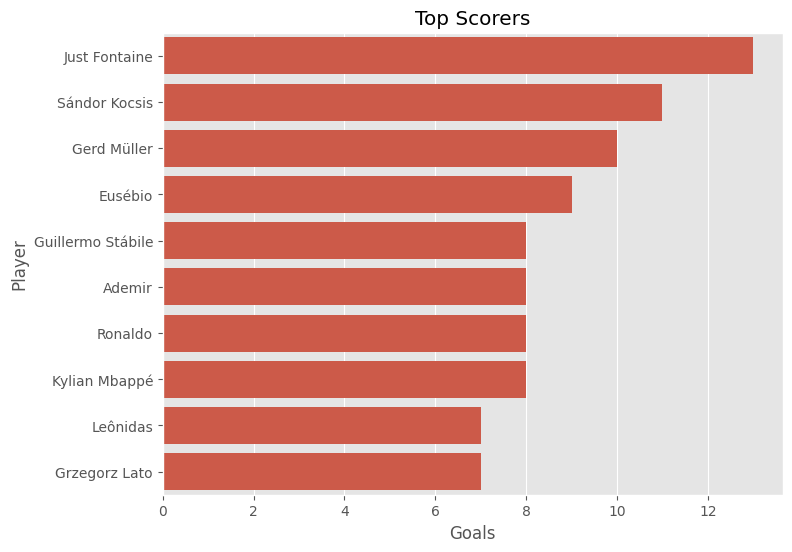

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x='goals',
    y='player'
)
print(top10)
plt.title('Top Scorers')
plt.xlabel('Goals')
plt.ylabel('Player')
plt.show()

In [ ]:
stage_goals = matches.groupby(
    'stage'
)['TotalGoals'].mean()
print(stage_goals)

stage
3rd Place           3.800000
Final               3.809524
Final Round         5.333333
Group Stage         3.745098
Quarter-final       2.724138
Round of 16         3.571429
Semi-final          3.405405
Semi-final Round    1.500000
Name: TotalGoals, dtype: float64


stage
3rd Place           3.800000
Final               3.809524
Final Round         5.333333
Group Stage         3.745098
Quarter-final       2.724138
Round of 16         3.571429
Semi-final          3.405405
Semi-final Round    1.500000
Name: TotalGoals, dtype: float64


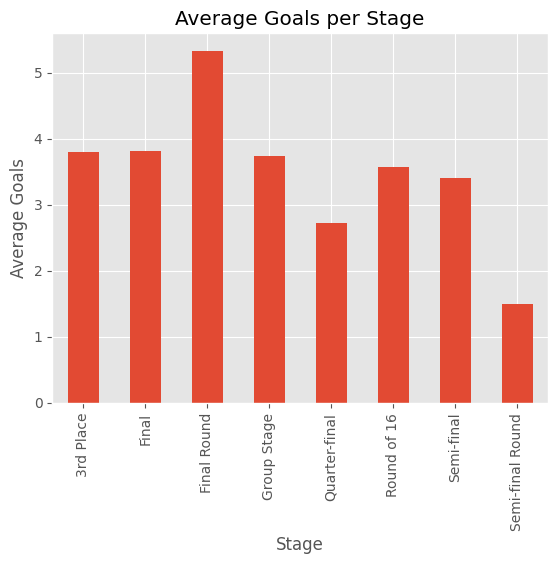

In [ ]:
stage_goals.plot(
    kind='bar'
)
print(stage_goals)
plt.title('Average Goals per Stage')
plt.xlabel('Stage')

plt.ylabel('Average Goals')
plt.show()

                year    score1    score2  TotalGoals
year        1.000000 -0.422592 -0.088589   -0.341682
score1     -0.422592  1.000000  0.259029    0.836558
score2     -0.088589  0.259029  1.000000    0.745872
TotalGoals -0.341682  0.836558  0.745872    1.000000


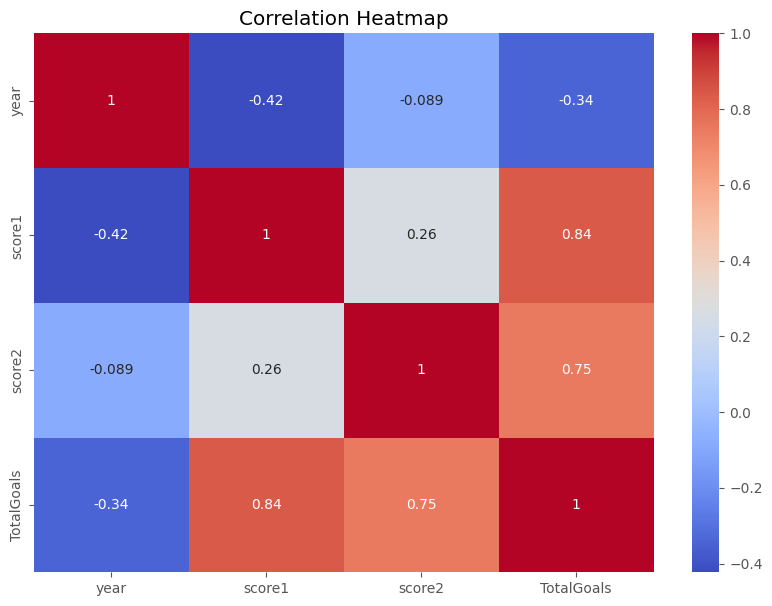

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(
    matches.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
print(matches.corr(numeric_only=True))
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
matches['GoalDifference'] = abs(
    matches['score1'] -
    matches['score2']
)
print(matches['GoalDifference'])

0      3
1      3
2      1
3      1
4      3
      ..
179    1
180    3
181    2
182    1
183    0
Name: GoalDifference, Length: 184, dtype: int64


In [ ]:
matches['CompetitiveMatch'] = np.where(
    matches['GoalDifference'] <= 1,
    1,
    0
)
print(matches['CompetitiveMatch'])

0      0
1      0
2      1
3      1
4      0
      ..
179    1
180    0
181    0
182    1
183    1
Name: CompetitiveMatch, Length: 184, dtype: int64


In [ ]:
Q1 = matches['TotalGoals'].quantile(.25)
print(Q1)
Q2 = matches['TotalGoals'].quantile(.50)
print(Q2)
Q3 = matches['TotalGoals'].quantile(.75)
print(Q3)
IQR = Q3 - Q1
print(IQR)

2.0
3.0
5.0
3.0


In [ ]:
outliers = matches[
    (matches['TotalGoals'] < Q1 - 1.5*IQR) |
    (matches['TotalGoals'] > Q3 + 1.5*IQR)
]
print(outliers)

    year          stage         team1  score1  score2        team2  \
15  1938    Round of 16        Brazil       6       5       Poland   
28  1954    Group Stage  West Germany       3       8      Hungary   
29  1954  Quarter-final       Austria       7       5  Switzerland   
35  1958    Group Stage        France       7       3     Paraguay   
57  1970    Group Stage  West Germany       3      10     Bulgaria   

                 venue        city      country        date  \
15  Stade de la Meinau  Strasbourg       France  1938-06-05   
28            Wankdorf        Bern  Switzerland  1954-06-20   
29            Hardturm    Lausanne  Switzerland  1954-06-26   
35       Idrottsparken  Norrköping       Sweden  1958-06-08   
57    Estadio Nou Camp        León       Mexico  1970-06-02   

                            notes  TotalGoals  GoalDifference  \
15                AET - 11 goals!          11               1   
28                            NaN          11               5   
29  H

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
from scipy.stats import f_oneway

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
fig = px.scatter(
    matches,
    x='GoalDifference',
    y='TotalGoals',
    color='stage'
)
fig.show()

GoalDifference
